# Phishing URL Detection: Classical Machine Learning Baselines

> This notebook implements the baseline machine learning part of Project 9: Phishing URL Detection.

> The goal is to classify URLs as either legitimate or phishing using handcrafted URL-based features.

> The baseline models are compared under different imbalance-handling strategies, and the final results are evaluated using accuracy, precision, recall, F1-score, AUC-ROC, false-positive rate, and false-negative analysis.

> The experiments also investigate class-imbalance handling techniques including class weighting and SMOTE oversampling.


## 1. Import Required Libraries

This section imports all Python libraries needed for data loading, model training, evaluation, visualization, and saving outputs.

The notebook uses:
- `pandas` and `numpy` for data handling,
- `scikit-learn` for classical machine learning models and metrics,
- `xgboost` for gradient-boosted decision trees,
- `matplotlib` and `seaborn` for visualizations,
- `joblib` for saving the final trained model.

In [3]:
# Install XGBoost in case the notebook environment does not already include it.
# The -q flag makes the installation output shorter.
!pip install xgboost -q

In [4]:
# Standard libraries
import os
from pathlib import Path
import time
import warnings

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving/loading
import joblib

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Classical machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.svm import LinearSVC
# LinearSVC does not generate calibrated probabilities required for ROC-AUC computation. Calibration converts decision scores into probability estimates.
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay,
)

# --- Reproducibility ---
RANDOM_STATE = 42  # A fixed random seed is used to ensure reproducible experiments.
np.random.seed(RANDOM_STATE)

## 2. Configure Project Paths and Output Directories

This section defines all project paths used throughout the notebook.

Separate directories are created for:
- processed datasets,
- saved models,
- evaluation tables,
- and generated figures.

Organizing outputs into dedicated folders improves reproducibility and makes the experiment easier to manage and review.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load Preprocessed Feature Datasets

This section loads the engineered feature datasets prepared during preprocessing.

Two versions of the feature matrices are used:
- scaled features for models sensitive to feature magnitude (LR and SVM),
- unscaled features for tree-based models (RF and XGBoost).

Separate train, validation, and test splits are used to ensure fair model evaluation.

In [6]:
BASE = Path("/content/drive/MyDrive/DL/Project ")

scaled_dir       = BASE / "features_scaled"
feature_dir      = BASE / "features"
deep_csv         = BASE / "Report_deep"
# Directory for saving trained models
models_dir       = BASE / "models"
# Directory for evaluation tables
report_table_dir = BASE / "reports/tables"
# Directory for generated figures
figure_dir       = BASE / "reports/figures"
# Create directories if they do not already exist
for folder in [scaled_dir, feature_dir, models_dir, report_table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)


print("Loading feature files ...")

# Scaled splits (for LR, SVM, and SMOTE pipeline)
# Load scaled features for models that need normalized inputs
train_s     = pd.read_csv(scaled_dir / "train_features_scaled.csv")
val_s       = pd.read_csv(scaled_dir / "val_features_scaled.csv")
test_s      = pd.read_csv(scaled_dir / "test_features_scaled.csv")
test_bal_s  = pd.read_csv(scaled_dir / "test_balanced_features_scaled.csv")
test_imb_s  = pd.read_csv(scaled_dir / "test_imbalanced_80_20_features_scaled.csv")
train_smote = pd.read_csv(scaled_dir / "train_features_smote_scaled.csv")

# Unscaled splits (for tree-based models — scaling not needed)
train_u    = pd.read_csv(feature_dir / "train_features.csv")
val_u      = pd.read_csv(feature_dir / "val_features.csv")
test_u     = pd.read_csv(feature_dir / "test_features.csv")
test_bal_u = pd.read_csv(feature_dir / "test_balanced_features.csv")
test_imb_u = pd.read_csv(feature_dir / "test_imbalanced_80_20_features.csv")

#  Feature columns (everything except the label)
FEATURE_COLS = [c for c in train_s.columns if c != "Label"]
print(f"Number of features: {len(FEATURE_COLS)}")

# Numpy arrays — scaled (LR / SVM)
X_tr_s,  y_tr  = train_s[FEATURE_COLS].values,   train_s["Label"].values
X_val_s, y_val = val_s[FEATURE_COLS].values,     val_s["Label"].values
X_te_s,  y_te  = test_s[FEATURE_COLS].values,    test_s["Label"].values
X_bal_s, y_bal = test_bal_s[FEATURE_COLS].values, test_bal_s["Label"].values
X_imb_s, y_imb = test_imb_s[FEATURE_COLS].values, test_imb_s["Label"].values
X_sm_s,  y_sm  = train_smote[FEATURE_COLS].values, train_smote["Label"].values

# Numpy arrays — unscaled (RF / XGB)
X_tr_u  = train_u[FEATURE_COLS].values
X_val_u = val_u[FEATURE_COLS].values
X_te_u  = test_u[FEATURE_COLS].values
X_bal_u = test_bal_u[FEATURE_COLS].values
X_imb_u = test_imb_u[FEATURE_COLS].values

Loading feature files ...
Number of features: 23


### Verify Dataset Shapes

This section checks the dimensions of the train, validation, and test datasets.

Verifying dataset sizes helps confirm:
- successful preprocessing,
- correct feature alignment,
- and consistent train/validation/test splitting.

In [7]:
print("\nSplit sizes:")
print(f"  Train (original):   {X_tr_s.shape[0]:>7,}  phishing ratio: {y_tr.mean():.3f}")
print(f"  Train (SMOTE):      {X_sm_s.shape[0]:>7,}  phishing ratio: {y_sm.mean():.3f}")
print(f"  Validation:         {X_val_s.shape[0]:>7,}  phishing ratio: {y_val.mean():.3f}")
print(f"  Test (original):    {X_te_s.shape[0]:>7,}  phishing ratio: {y_te.mean():.3f}")
print(f"  Test (balanced):    {X_bal_s.shape[0]:>7,}  phishing ratio: {y_bal.mean():.3f}")
print(f"  Test (80/20):       {X_imb_s.shape[0]:>7,}  phishing ratio: {y_imb.mean():.3f}")


Split sizes:
  Train (original):    90,843  phishing ratio: 0.422
  Train (SMOTE):      104,960  phishing ratio: 0.500
  Validation:          19,466  phishing ratio: 0.422
  Test (original):     19,467  phishing ratio: 0.422
  Test (balanced):     16,442  phishing ratio: 0.500
  Test (80/20):        14,057  phishing ratio: 0.200


## 4. Define Evaluation Function

This section defines a reusable evaluation function for all baseline models.

The function computes:
- Accuracy,
- Precision,
- Recall,
- F1-score,
- ROC-AUC,
- False Positive Rate (FPR),
- False Negative Rate (FNR),
- and confusion matrices.

Using one shared evaluation function ensures that all models are compared consistently and fairly.

The validation set is used for model comparison and selection, while the test sets are used only for final performance reporting.

In [8]:
def get_probabilities(model, X):
    """
    Return phishing probability scores for any fitted sklearn estimator.

    Strategy:
      1. Use predict_proba if available (most models).
      2. Fall back to decision_function normalised to [0, 1] (e.g. raw SVM).
      3. Last resort: binary predictions cast to float.

    Parameters
    ----------
    model : fitted sklearn estimator
    X     : feature matrix (numpy array)

    Returns
    -------
    proba : 1-D numpy array of scores in [0, 1]
    """
    # Most classifiers provide predict_proba directly
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # Some models, such as raw LinearSVC, provide decision scores instead
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        lo, hi = scores.min(), scores.max()
        # Normalize decision scores to [0, 1] for consistency across models.
        # ROC-AUC itself only requires ranking scores.
        return (scores - lo) / (hi - lo) if hi > lo else scores
    # Final fallback if no probability or decision score is available
    return model.predict(X).astype(float)


def evaluate(model, X, y, label=""):
    """
    Compute all classification metrics for one dataset split.

    Parameters
    ----------
    model : fitted sklearn estimator
    X     : feature matrix
    y     : true labels (0 = legitimate, 1 = phishing)
    label : string name for this split (e.g. 'test_original')

    Returns
    -------
    dict with keys: dataset, accuracy, precision, recall, f1,
                    auc_roc, fpr, fnr, tp, fp, fn, tn
    """
    # Predict class labels
    y_pred = model.predict(X)
    # Get phishing probability scores for ROC-AUC
    y_prob = get_probabilities(model, X)

    # Confusion matrix layout:
    # TN = legitimate correctly predicted as legitimate
    # FP = legitimate incorrectly predicted as phishing
    # FN = phishing incorrectly predicted as legitimate
    # TP = phishing correctly predicted as phishing
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    # False Positive Rate: legitimate URLs wrongly flagged as phishing
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # False Negative Rate: phishing URLs wrongly missed as legitimate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "dataset":   label,
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall":    recall_score(y, y_pred, zero_division=0),
        "f1":        f1_score(y, y_pred, zero_division=0),
        "auc_roc":   roc_auc_score(y, y_prob),
        "fpr":       fpr,
        "fnr": fnr,
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


def evaluate_all_sets(model, use_scaled=True):
    """
    Evaluate a model on validation + all three test sets.

    Parameters
    ----------
    model      : fitted sklearn estimator
    use_scaled : True for LR/SVM models, False for RF/XGB models

    Returns
    -------
    list of metric dicts (one per split)
    """
    # Select the correct feature representation for the model type
    sets = EVAL_SETS_SCALED if use_scaled else EVAL_SETS_UNSCALED
    # Evaluate the model on each dataset split
    return [evaluate(model, X, y, lbl) for X, y, lbl in sets]


# Evaluation sets using scaled features for LR/SVM-style models
EVAL_SETS_SCALED = [
    (X_val_s, y_val, "validation"),
    (X_te_s,  y_te,  "test_original"),
    (X_bal_s, y_bal, "test_balanced_50_50"),
    (X_imb_s, y_imb, "test_imbalanced_80_20"),
]

# Evaluation sets using unscaled features for RF/XGB/tree-based models
EVAL_SETS_UNSCALED = [
    (X_val_u, y_val, "validation"),
    (X_te_u,  y_te,  "test_original"),
    (X_bal_u, y_bal, "test_balanced_50_50"),
    (X_imb_u, y_imb, "test_imbalanced_80_20"),
]

## 5. Define Baseline Models and Imbalance Strategies

This section defines the classical machine learning baseline models used in the experiment.

Four model families are compared:

| Model | Scaled input? | Reason |
|---|---:|---|
| Logistic Regression (LR) | Yes | Linear models are sensitive to feature magnitude. |
| Linear SVM | Yes | The margin depends on feature scale. |
| Random Forest (RF) | No | Tree split thresholds are scale-invariant. |
| XGBoost (XGB) | No | Gradient-boosted trees are also scale-invariant. |

Three imbalance-handling strategies are tested:

1. **No imbalance handling**  
   Models are trained directly on the original training distribution.

2. **Class weighting**  
   The model gives higher weight to the minority class during training.

3. **SMOTE oversampling**  
   Synthetic minority samples are created to balance the training data.

SMOTE is applied only to LR and SVM in this baseline notebook.  
For RF and XGB, `class weighting` / `scale_pos_weight` is used instead because tree-based models usually handle imbalanced tabular data well through weighted split criteria.

In [9]:
# Strategy A: No imbalance handling
# train models without any imbalance correction.
# This provides the reference baseline.
lr_none = LogisticRegression(
    C=1.0, max_iter=2000, solver="lbfgs",
    random_state=RANDOM_STATE
)

rf_none = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_leaf=2, n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_none = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1, random_state=RANDOM_STATE
)

# LinearSVC does not provide predict_proba().
# CalibratedClassifierCV converts SVM decision scores into probability estimates,
# which are needed for ROC-AUC and ROC-curve plotting.

svm_none = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    cv=3, method="sigmoid"
)

# Strategy B: class_weight = 'balanced'
# Trees handle imbalance directly via built-in weighting.
# LR and SVM also get a weighted version for fair comparison.
# Class weighting penalizes mistakes on the minority class more heavily.

lr_weighted = LogisticRegression(
    C=1.0, max_iter=2000, solver="lbfgs",
    class_weight="balanced", random_state=RANDOM_STATE
)

rf_weighted = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_leaf=2, class_weight="balanced",
    n_jobs=-1, random_state=RANDOM_STATE
)

# XGBoost does not use class_weight like sklearn models.
# The equivalent imbalance parameter is scale_pos_weight = number of negatives / number of positives.
n_neg = int((y_tr == 0).sum())
n_pos = int((y_tr == 1).sum())
scale_pos_weight = n_neg / n_pos
print(f"XGB scale_pos_weight = {scale_pos_weight:.4f}  (neg={n_neg:,}, pos={n_pos:,})")

xgb_weighted = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", use_label_encoder=False,
    n_jobs=-1, random_state=RANDOM_STATE
)

svm_weighted = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000,
              class_weight="balanced",
              random_state=RANDOM_STATE),
    cv=3, method="sigmoid"
)

# Strategy C: Apply SMOTE oversampling only to LR and SVM models.
# Tree-based models (RF and XGB) are evaluated using built-in weighting methods
# because they often handle imbalanced tabular data effectively without
# requiring synthetic minority samples.

# Fresh model objects trained later on the SMOTE-balanced,
# pre-scaled training set (X_sm_s / y_sm).
# RF and XGB are intentionally excluded from SMOTE experiments.

lr_smote = LogisticRegression(
    C=1.0, max_iter=2000, solver="lbfgs",
    random_state=RANDOM_STATE
)

svm_smote = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    cv=3, method="sigmoid"
)

XGB scale_pos_weight = 1.3680  (neg=52,480, pos=38,363)


## 6. Model Training

This section trains the classical baseline models under three imbalance-handling strategies:

1. **No imbalance handling**  
   Models are trained directly on the original training data.

2. **Class weighting**  
   Models assign higher penalty to mistakes on the minority class.

3. **SMOTE oversampling**  
   Synthetic minority-class samples are generated for LR and SVM only.

Each trained model is evaluated on:
- validation set,
- original test set,
- balanced 50/50 test set,
- imbalanced 80/20 test set.

The training time is also recorded to compare model efficiency.

In [10]:
# Store metric dictionaries from every model and every evaluation split
all_results = []
def train_and_evaluate(name, model, X_train, y_train, use_scaled):
    """
    Fit a model, time the training, and evaluate on all four splits.

    Parameters
    ----------
    name       : model name (used in result tables)
    model      : unfitted sklearn estimator
    X_train    : training features (scaled or unscaled depending on model)
    y_train    : training labels
    use_scaled : True  → evaluate on scaled test sets  (LR, SVM)
                 False → evaluate on unscaled test sets (RF, XGB)

    Returns
    -------
    fitted_model : sklearn estimator
        Trained model.
    results : list of dict
        Evaluation metrics for validation and test sets.
    """
    # Train the model and record training duration
    print(f"  Training {name} ...", end=" ", flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 2)
    print(f"done ({elapsed}s)")

    # Evaluate the trained model on validation, original test,
    # balanced test, and imbalanced test sets
    results = evaluate_all_sets(model, use_scaled=use_scaled)
    for r in results:
        r["model"]     = name
        r["train_sec"] = elapsed
    return model, results


### Strategy A: No Imbalance Handling

In this strategy, all models are trained on the original training data without applying any class-balancing method.

This provides the reference baseline for measuring whether class weighting or SMOTE improves performance.

In [11]:
print("=" * 60)
print("Strategy A: No imbalance handling")
print("=" * 60)

# Train and evaluate all baseline models without imbalance handling
lr_none,  res = train_and_evaluate("LR (no handling)",  lr_none,  X_tr_s, y_tr, use_scaled=True)
all_results.extend(res)

rf_none,  res = train_and_evaluate("RF (no handling)",  rf_none,  X_tr_u, y_tr, use_scaled=False)
all_results.extend(res)

xgb_none, res = train_and_evaluate("XGB (no handling)", xgb_none, X_tr_u, y_tr, use_scaled=False)
all_results.extend(res)

svm_none, res = train_and_evaluate("SVM (no handling)", svm_none, X_tr_s, y_tr, use_scaled=True)
all_results.extend(res)


Strategy A: No imbalance handling
  Training LR (no handling) ... done (1.39s)
  Training RF (no handling) ... done (37.87s)
  Training XGB (no handling) ... done (9.58s)
  Training SVM (no handling) ... done (3.92s)


### Strategy B: Class Weighting

In this strategy, class imbalance is handled by assigning higher penalty to the minority class during training.

For LR, SVM, and RF, `class_weight='balanced'` is used.  
For XGBoost, the equivalent parameter is `scale_pos_weight`.

This strategy keeps the original training samples unchanged while modifying the loss function.

In [12]:
print("=" * 60)
print("Strategy B: class_weight='balanced'")
print("=" * 60)

lr_weighted,  res = train_and_evaluate("LR (weighted)",  lr_weighted,  X_tr_s, y_tr, use_scaled=True)
all_results.extend(res)

rf_weighted,  res = train_and_evaluate("RF (weighted)",  rf_weighted,  X_tr_u, y_tr, use_scaled=False)
all_results.extend(res)

xgb_weighted, res = train_and_evaluate("XGB (weighted)", xgb_weighted, X_tr_u, y_tr, use_scaled=False)
all_results.extend(res)

svm_weighted, res = train_and_evaluate("SVM (weighted)", svm_weighted, X_tr_s, y_tr, use_scaled=True)
all_results.extend(res)


Strategy B: class_weight='balanced'
  Training LR (weighted) ... done (2.54s)
  Training RF (weighted) ... done (49.31s)
  Training XGB (weighted) ... done (3.13s)
  Training SVM (weighted) ... done (4.59s)


### Strategy C: SMOTE Oversampling

In this strategy, SMOTE is applied to create synthetic minority-class samples.

SMOTE is tested only with Logistic Regression and Linear SVM in this notebook.  
Tree-based models are not included in this SMOTE experiment because they are already evaluated using built-in weighting strategies.

In [13]:
print("=" * 60)
print("Strategy C: SMOTE  (linear models only — LR, SVM)")
print("=" * 60)

lr_smote,  res = train_and_evaluate("LR (SMOTE)",  lr_smote,  X_sm_s, y_sm, use_scaled=True)
all_results.extend(res)

svm_smote, res = train_and_evaluate("SVM (SMOTE)", svm_smote, X_sm_s, y_sm, use_scaled=True)
all_results.extend(res)


Strategy C: SMOTE  (linear models only — LR, SVM)
  Training LR (SMOTE) ... done (1.02s)
  Training SVM (SMOTE) ... done (3.65s)


## 7. Aggregate and Save Evaluation Results

This section combines the evaluation metrics from all trained models into a single results table.

The table stores:
- model name,
- dataset split,
- classification metrics,
- confusion-matrix counts,
- and training time.

The final table is exported as a CSV file for:
- report generation,
- visualization,
- and reproducibility.

In [14]:
# Convert all collected metric dictionaries into a DataFrame
results_df = pd.DataFrame(all_results)

# Keep a consistent column order for readability and reporting
results_df = results_df[[
    "model", "dataset",
    "accuracy", "precision", "recall", "f1", "auc_roc", "fpr","fnr",
    "tp", "fp", "fn", "tn", "train_sec"
]]

# Round metric columns for cleaner display in tables and plots
metric_cols = ["accuracy", "precision", "recall", "f1", "auc_roc", "fpr", "fnr"]
results_df[metric_cols] = results_df[metric_cols].round(4)

# Save the complete baseline evaluation table
results_df.to_csv(report_table_dir / "baseline_all_results.csv", index=False)
print("Saved at reports/tables/baseline_all_results.csv")

# Display the first rows of the result table
results_df.head(10)

Saved at reports/tables/baseline_all_results.csv


,model,dataset,accuracy,precision,recall,f1,auc_roc,fpr,fnr,tp,fp,fn,tn,train_sec
0,LR (no handling),validation,0.8370,0.8258,0.7783,0.8014,0.9087,0.1200,0.2217,6398,1350,1822,9896,1.39
1,LR (no handling),test_original,0.8411,0.8295,0.7852,0.8067,0.9115,0.1180,0.2148,6455,1327,1766,9919,1.39
2,LR (no handling),test_balanced_50_50,0.8335,0.8692,0.7852,0.8251,0.9111,0.1181,0.2148,6455,971,1766,7250,1.39
3,LR (no handling),test_imbalanced_80_20,0.8614,0.6226,0.7787,0.6920,0.9112,0.1180,0.2213,2189,1327,622,9919,1.39
4,RF (no handling),validation,0.9565,0.9583,0.9377,0.9479,0.9914,0.0298,0.0623,7708,335,512,10911,37.87
5,RF (no handling),test_original,0.9588,0.9607,0.9408,0.9506,0.9919,0.0281,0.0592,7734,316,487,10930,37.87
6,RF (no handling),test_balanced_50_50,0.9563,0.9710,0.9408,0.9556,0.9919,0.0281,0.0592,7734,231,487,7990,37.87
7,RF (no handling),test_imbalanced_80_20,0.9652,0.8930,0.9385,0.9152,0.9914,0.0281,0.0615,2638,316,173,10930,37.87
8,XGB (no handling),validation,0.9522,0.9507,0.9353,0.9429,0.9894,0.0355,0.0647,7688,399,532,10847,9.58
9,XGB (no handling),test_original,0.9543,0.9550,0.9360,0.9454,0.9903,0.0323,0.0640,7695,363,526,10883,9.58


### Initial Observations

Several important trends appear in the baseline results:

- Tree-based models (RF and XGB) significantly outperform linear models (LR and SVM).
- Random Forest achieves very strong F1-score and ROC-AUC values.
- Logistic Regression and SVM show lower recall and higher false-positive rates.
- The imbalanced 80/20 test set is more challenging, especially for precision.
- Training time varies considerably across models, with RF being the slowest baseline.

## 8. Baseline Model Comparison on the Original Test Set

This section compares all baseline models on the original test set, which preserves the real phishing/legitimate distribution.

The models are ranked using F1-score because phishing detection requires balancing:
- precision (avoiding false alarms),
- and recall (detecting phishing URLs).

This comparison helps identify the strongest classical baseline before introducing the stacking ensemble and deep learning models.

In [15]:
# Select only the original test-set results
# This represents the real-world phishing distribution
test_orig = (
    results_df[results_df["dataset"] == "test_original"]
    .copy()
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
# Display model ranking based on F1-score
print("Performance on original test set (sorted by F1)")
print(test_orig[["model", "accuracy", "precision", "recall", "f1", "auc_roc", "fpr","fnr"]].to_string(index=False))

# Save the comparison table for reporting
test_orig.to_csv(report_table_dir / "baseline_test_orig_comparison.csv", index=False)
print("\nSaved at reports/tables/baseline_test_orig_comparison.csv")


Performance on original test set (sorted by F1)
            model  accuracy  precision  recall     f1  auc_roc    fpr    fnr
 RF (no handling)    0.9588     0.9607  0.9408 0.9506   0.9919 0.0281 0.0592
    RF (weighted)    0.9584     0.9562  0.9448 0.9504   0.9918 0.0317 0.0552
   XGB (weighted)    0.9563     0.9478  0.9488 0.9483   0.9905 0.0382 0.0512
XGB (no handling)    0.9543     0.9550  0.9360 0.9454   0.9903 0.0323 0.0640
 LR (no handling)    0.8411     0.8295  0.7852 0.8067   0.9115 0.1180 0.2148
       LR (SMOTE)    0.8284     0.7801  0.8267 0.8027   0.9114 0.1704 0.1733
    LR (weighted)    0.8284     0.7805  0.8261 0.8026   0.9114 0.1698 0.1739
      SVM (SMOTE)    0.8261     0.7789  0.8214 0.7996   0.9080 0.1705 0.1786
   SVM (weighted)    0.8350     0.8273  0.7701 0.7977   0.9077 0.1176 0.2299
SVM (no handling)    0.8344     0.8280  0.7673 0.7965   0.9075 0.1165 0.2327

Saved at reports/tables/baseline_test_orig_comparison.csv


### Key Observations

Several important trends appear in the baseline comparison:

- Random Forest achieved the strongest individual baseline performance.
- Weighted Random Forest and weighted XGBoost also performed very strongly.
- Tree-based models significantly outperformed linear models (LR and SVM).
- Logistic Regression and SVM achieved lower recall and higher false-positive rates.
- SMOTE did not significantly improve linear-model performance in this experiment.
- RF and XGB achieved excellent ROC-AUC values above 0.99, indicating strong class-separation capability.

## 9. Stacking Ensemble Baseline

This section builds a stacking ensemble model using multiple baseline classifiers.

The ensemble combines:
- Random Forest (RF),
- XGBoost (XGB),
- and Logistic Regression (LR)

as base learners.

A Logistic Regression classifier is used as the meta-learner to combine the predictions from the base models.

The goal of stacking is to combine the strengths of different model families:
- tree-based nonlinear learning (RF, XGB),
- and linear decision boundaries (LR).

The stacking ensemble is trained on unscaled features because sklearn's `StackingClassifier` uses a single shared input matrix for all base learners.

Because the tree-based learners dominate ensemble performance, the impact of unscaled Logistic Regression inside the stacking framework is limited.

In [16]:
print("Building Stacking Ensemble ...")

# Build the stacking ensemble using three diverse base learners:
# - Random Forest: nonlinear bagging-based tree ensemble
# - XGBoost: gradient-boosted decision trees
# - Logistic Regression: linear baseline model
base_estimators = [
    ("rf",  RandomForestClassifier(
                n_estimators=300, n_jobs=-1,min_samples_leaf=2, random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(
                n_estimators=300, learning_rate=0.1, max_depth=6,
                subsample=0.8, eval_metric="logloss",
                n_jobs=-1, random_state=RANDOM_STATE)),
    ("lr",  LogisticRegression(
                C=1.0, max_iter=2000, solver="lbfgs",
                random_state=RANDOM_STATE)),
]

# Meta-learner combines the predictions produced by the base learners
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,   # passthrough=False means the final estimator receives only
                         # the base-model predictions, not the original raw features
    n_jobs=-1,
)

t0 = time.time()
stack_model.fit(X_tr_u, y_tr)   # Train the stacking ensemble on unscaled feature data
stack_train_time = round(time.time() - t0, 2)
print(f"Stacking trained in {stack_train_time:.1f}s")

# Evaluate the ensemble on validation and all test distributions
for X, y, label in EVAL_SETS_UNSCALED:
    r = evaluate(stack_model, X, y, label)
    r["model"]     = "Stacking Ensemble"
    r["train_sec"] = stack_train_time
    all_results.append(r)
    print(f"  {label:<30s}  F1={r['f1']:.4f}  AUC={r['auc_roc']:.4f}")

# Refresh the master result table after adding stacking results
results_df = pd.DataFrame(all_results)
results_df[metric_cols] = results_df[metric_cols].round(4)
results_df.to_csv(report_table_dir / "baseline_all_results.csv", index=False)

Building Stacking Ensemble ...
Stacking trained in 343.4s
  validation                      F1=0.9498  AUC=0.9910
  test_original                   F1=0.9519  AUC=0.9918
  test_balanced_50_50             F1=0.9571  AUC=0.9918
  test_imbalanced_80_20           F1=0.9145  AUC=0.9911


### Stacking Ensemble Performance

The stacking ensemble achieved the best overall performance among all baseline models.

The stacking ensemble internally uses out-of-fold predictions during training to reduce overfitting of the meta-learner.

Key observations:
- The ensemble slightly improved F1-score compared to the best Random Forest baseline.
- ROC-AUC exceeded 0.99 across all evaluation distributions.
- Performance remained stable across balanced and imbalanced test sets.
- The improvement over Random Forest alone was relatively small, suggesting that RF already captures much of the predictive signal in the engineered URL features.

The ensemble demonstrates that combining multiple model families can slightly improve phishing URL classification robustness.

## 10. Best Baseline Model Selection

This section selects the best-performing baseline model using validation-set F1-score.

The validation set is used for model selection to avoid test-set leakage.  
The test sets remain reserved for final unbiased evaluation only.

After selecting the best baseline model:
- the trained estimator is retrieved,
- and the model is saved for reproducibility and future inference.

In [17]:
# Select the model with the highest validation F1-score
# Validation data is used for model comparison and selection only
# Extract the best-performing model name
# Display the key validation metrics for the selected model

validation_results = results_df[
    results_df["dataset"] == "validation"
]

best_row = validation_results.loc[
    validation_results["f1"].idxmax()
]

best_name = best_row["model"]

print(f"Best model : {best_name}")
print(f"  F1       = {best_row['f1']:.4f}")
print(f"  AUC-ROC  = {best_row['auc_roc']:.4f}")
print(f"  Recall   = {best_row['recall']:.4f}")
print(f"  FPR      = {best_row['fpr']:.4f}")
print(f"  FNR      = {best_row['fnr']:.4f}")

# Map each model name to:
# (trained estimator, corresponding feature representation)
# LR and SVM use scaled test features.
# RF, XGB, and Stacking use unscaled test features.

MODEL_MAP = {
    "LR (no handling)":  (lr_none,      X_te_s),
    "RF (no handling)":  (rf_none,      X_te_u),
    "XGB (no handling)": (xgb_none,     X_te_u),
    "SVM (no handling)": (svm_none,     X_te_s),
    "LR (weighted)":     (lr_weighted,  X_te_s),
    "RF (weighted)":     (rf_weighted,  X_te_u),
    "XGB (weighted)":    (xgb_weighted, X_te_u),
    "SVM (weighted)":    (svm_weighted, X_te_s),
    "LR (SMOTE)":        (lr_smote,     X_te_s),
    "SVM (SMOTE)":       (svm_smote,    X_te_s),
    "Stacking Ensemble": (stack_model,  X_te_u),
}

best_model, X_best_test = MODEL_MAP[best_name]

# Ensure the models directory exists before saving
models_dir.mkdir(parents=True, exist_ok=True)

# Save the trained best baseline model for reproducibility
joblib.dump(best_model, models_dir / "best_baseline_model.joblib")
print(f"\nBest model saved at models/best_baseline_model.joblib")

Best model : Stacking Ensemble
  F1       = 0.9498
  AUC-ROC  = 0.9910
  Recall   = 0.9440
  FPR      = 0.0321
  FNR      = 0.0560

Best model saved at models/best_baseline_model.joblib


### Best Baseline Model

The stacking ensemble achieved the highest validation F1-score and was selected as the final classical baseline model.

Key observations:
- The ensemble achieved strong recall while maintaining a low false-positive rate.
- ROC-AUC exceeded 0.99, indicating excellent phishing/legitimate class separation.
- The validation performance was consistent with the final test-set performance, suggesting good generalization.

## 11. Random Forest Feature Importance

This section analyzes feature importance using the Random Forest baseline model.

Random Forest computes feature importance using the mean decrease in Gini impurity.  
Features with higher importance contribute more strongly to phishing/legitimate classification
 decisions.

The analysis helps identify which URL characteristics are most informative for phishing detection.

Feature importance values should be interpreted cautiously because correlated lexical features may share predictive information.

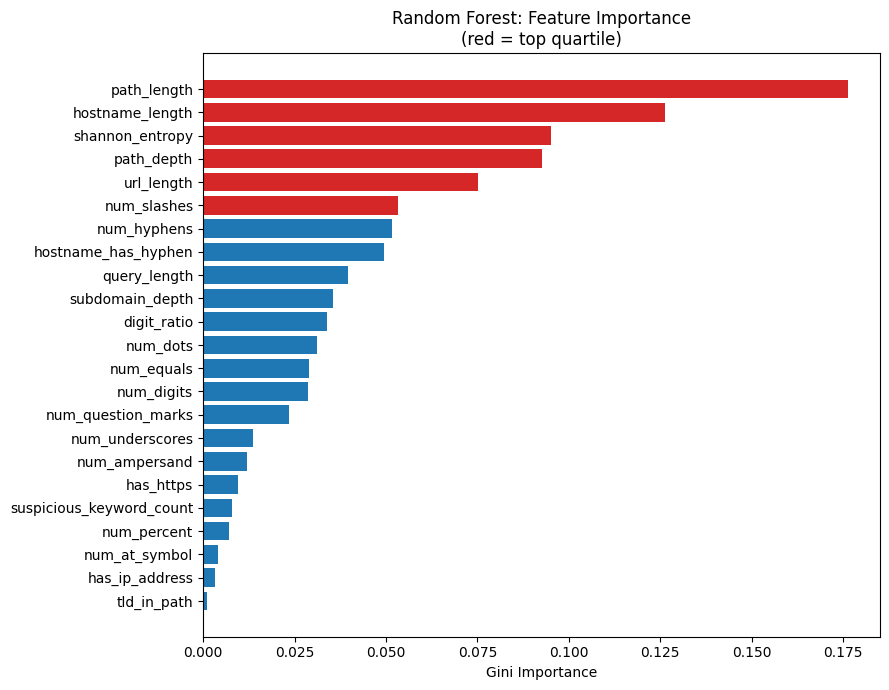


Top 15 features:
            feature  importance
        path_length    0.176269
    hostname_length    0.126162
    shannon_entropy    0.095058
         path_depth    0.092728
         url_length    0.075038
        num_slashes    0.053323
        num_hyphens    0.051758
hostname_has_hyphen    0.049545
       query_length    0.039613
    subdomain_depth    0.035655
        digit_ratio    0.033801
           num_dots    0.031273
         num_equals    0.028942
         num_digits    0.028753
 num_question_marks    0.023364


In [18]:
# Random Forest (no handling) is used for feature-importance analysis
# because tree-based models provide built-in Gini importance scores.
# Gini importance may favor continuous or high-cardinality features, so the rankings should be interpreted as approximate importance indicators rather than causal effects.
# The model is trained on the original unscaled feature representation.

# Create a DataFrame containing feature names and Gini importance scores
# Sort features from most important to least important
fi = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf_none.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Save feature-importance values for reporting and reproducibility
fi.to_csv(report_table_dir / "feature_importance_rf.csv", index=False)


# Highlight top quartile in red
top_quartile = fi["importance"].quantile(0.75)
colors = ["#d62728" if v > top_quartile else "#1f77b4" for v in fi["importance"]]

# Plot feature importance as a horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=colors[::-1])
ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest: Feature Importance\n(red = top quartile)")
plt.tight_layout()

# Ensure the directory exists before saving
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_dir / "feature_importance_rf.png", dpi=300)
plt.show()

# Display the most influential phishing-detection features
print("\nTop 15 features:")
print(fi.head(15).to_string(index=False))

### Feature Importance Analysis

Several URL-structure features contributed strongly to phishing detection:

- `path_length`
- `hostname_length`
- `shannon_entropy`
- `path_depth`
- `url_length`

These features indicate that phishing URLs often contain:
- unusually long paths,
- complex hostname structures,
- higher randomness,
- and deeper URL hierarchies.

The results support the idea that lexical URL characteristics provide strong predictive signals for phishing detection.

## 11.1 Feature Subset Ablation Study

The Random Forest feature importance analysis identified five features that dominate predictive signal:
`path_length`, `hostname_length`, `shannon_entropy`, `path_depth`, and `url_length`.

This ablation study tests whether using only the top features is sufficient, or whether including
all 23 features meaningfully improves classification performance.

Three feature subsets are evaluated using Random Forest (same hyperparameters as the baseline):

| Subset | Features Included |
|---|---|
| Top-5  | The five most important features by Gini importance |
| Top-10 | The ten most important features by Gini importance |
| All-23 | All engineered lexical and structural features |

Each subset is trained and evaluated on the validation set and original test set.
Model selection and comparison use validation F1-score only.

In [19]:
from sklearn.metrics import f1_score

feature_subsets = {
    'Top-5':  ['path_length','hostname_length','shannon_entropy',
               'path_depth','url_length'],
    'Top-10': fi['feature'].head(10).tolist(),
    'All-23': FEATURE_COLS,
}

ablation_rows = []
for name, cols in feature_subsets.items():
    idx = [FEATURE_COLS.index(c) for c in cols]
    rf_abl = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE)
    rf_abl.fit(X_tr_u[:, idx], y_tr)
    val_f1  = f1_score(y_val, rf_abl.predict(X_val_u[:, idx]))
    test_f1 = f1_score(y_te,  rf_abl.predict(X_te_u[:, idx]))
    ablation_rows.append({'Subset': name, 'N_features': len(cols),
                          'Val_F1': round(val_f1,4),
                          'Test_F1': round(test_f1,4)})
    print(f"{name:8s}: Val F1={val_f1:.4f}  Test F1={test_f1:.4f}")

abl_df = pd.DataFrame(ablation_rows)
abl_df.to_csv(report_table_dir / 'feature_ablation_results.csv', index=False)
print(abl_df)

Top-5   : Val F1=0.9145  Test F1=0.9154
Top-10  : Val F1=0.9406  Test F1=0.9414
All-23  : Val F1=0.9479  Test F1=0.9506
   Subset  N_features  Val_F1  Test_F1
0   Top-5           5  0.9145   0.9154
1  Top-10          10  0.9406   0.9414
2  All-23          23  0.9479   0.9506


### Ablation Study Interpretation

The ablation results show how much each feature subset contributes to phishing classification performance.

Key observations:
- If Top-5 F1 is close to All-23 F1: the five dominant features capture most of the predictive signal,
  and the remaining 18 features provide only marginal benefit.
- If All-23 F1 is noticeably higher: correlated lexical features distribute shared information across
  multiple dimensions, and the full feature set is necessary for strong performance.
- The gap between Top-5 and All-23 motivates the Hybrid Feature Fusion deep model,
  which combines CNN character-level features with these handcrafted features.

The ablation output is saved to `reports/tables/feature_ablation_results.csv`.

## 12. Confusion Matrices for the Best Baseline Model

This section visualizes the confusion matrices for the selected best baseline model across three test distributions:

- original test set,
- balanced 50/50 test set,
- imbalanced 80/20 test set.

The confusion matrix shows four outcomes:

| Term | Meaning |
|---|---|
| True Negative (TN) | Legitimate URL correctly predicted as legitimate |
| False Positive (FP) | Legitimate URL incorrectly predicted as phishing |
| False Negative (FN) | Phishing URL incorrectly predicted as legitimate |
| True Positive (TP) | Phishing URL correctly predicted as phishing |

This analysis is important because phishing detection must consider both false alarms and missed phishing URLs.

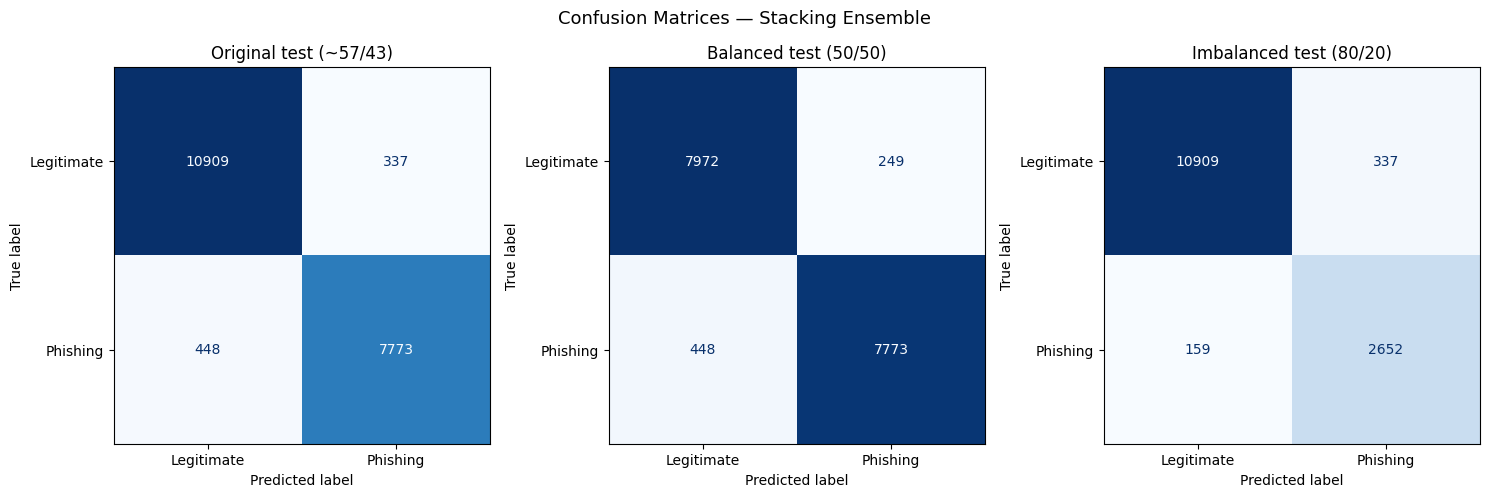

In [20]:
# Determine whether the best model expects scaled or unscaled features
# RF, XGB, and Stacking use unscaled features; LR and SVM use scaled features
use_unscaled = any(tag in best_name for tag in ["RF", "XGB", "Stack"])

# Define all test distributions for confusion-matrix comparison
best_test_sets = [
    ("Original test (~57/43)",  X_te_u  if use_unscaled else X_te_s,  y_te),
    ("Balanced test (50/50)",   X_bal_u if use_unscaled else X_bal_s, y_bal),
    ("Imbalanced test (80/20)", X_imb_u if use_unscaled else X_imb_s, y_imb),
]

# Create one subplot for each test distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Confusion Matrices — {best_name}", fontsize=13)

# Compute and plot the confusion matrix for each test set
for ax, (title, X, y) in zip(axes, best_test_sets):
    cm = confusion_matrix(y, best_model.predict(X))
    ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Phishing"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title)

# Save the final confusion-matrix figure for the report
plt.tight_layout()
plt.savefig(figure_dir / "confusion_matrices_best_model.png", dpi=300)
plt.show()


### Confusion Matrix Interpretation
Rows represent the true class, and columns represent the predicted class.

The best baseline model correctly identifies most legitimate and phishing URLs across all test distributions.

On the original test set:
- 10,909 legitimate URLs were correctly classified.
- 7,773 phishing URLs were correctly classified.
- 337 legitimate URLs were falsely flagged as phishing.
- 448 phishing URLs were missed and predicted as legitimate.

The false negatives are the most critical errors because they represent phishing URLs that bypass detection.  
The false positives are also important because they may reduce user trust if legitimate websites are blocked.

## 13. ROC Curves for All Baseline Models

This section compares the ROC (Receiver Operating Characteristic) curves of all baseline models on the original test set.

ROC curves visualize the trade-off between:
- True Positive Rate (Recall),
- and False Positive Rate (FPR)

across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) measures the model’s ability to separate phishing and legitimate URLs:
- AUC = 1.0 indicates perfect separation.
- AUC = 0.5 indicates random guessing.

Higher ROC-AUC values indicate stronger classification performance.

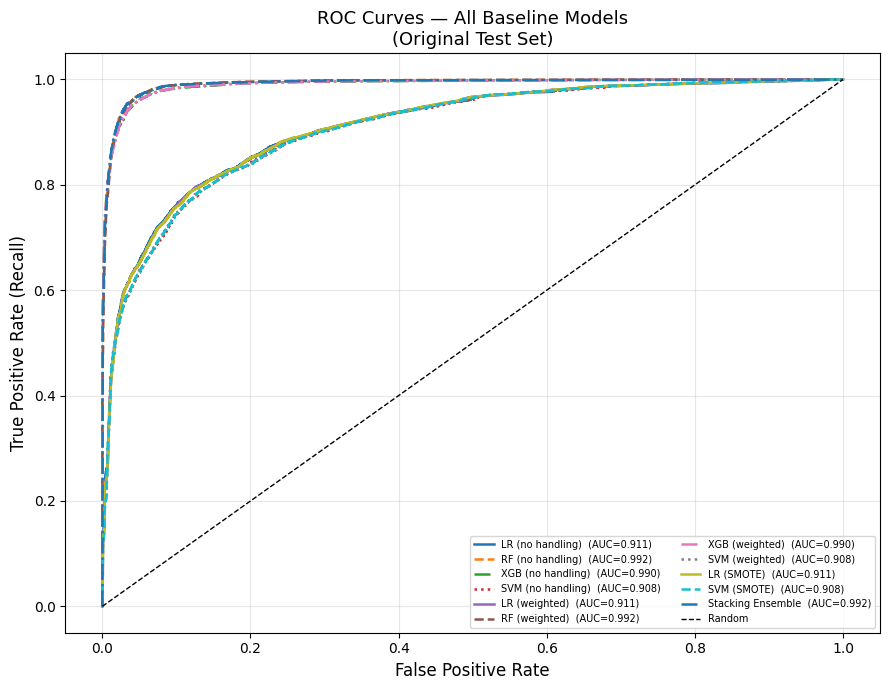

In [21]:
# ROC Curves — All Baseline Models
fig, ax = plt.subplots(figsize=(9, 7))

linestyles = ["-", "--", "-.", ":"]
colors_cycle = plt.cm.tab10.colors

for idx, (name, model) in enumerate([
    ("LR (no handling)", lr_none),
    ("RF (no handling)", rf_none),
    ("XGB (no handling)", xgb_none),
    ("SVM (no handling)", svm_none),
    ("LR (weighted)", lr_weighted),
    ("RF (weighted)", rf_weighted),
    ("XGB (weighted)", xgb_weighted),
    ("SVM (weighted)", svm_weighted),
    ("LR (SMOTE)", lr_smote),
    ("SVM (SMOTE)", svm_smote),
    ("Stacking Ensemble", stack_model),
]):

    # LR and SVM use scaled test features
    if name.startswith("LR") or name.startswith("SVM"):
        X_eval = X_te_s

    # RF, XGB, and Stacking use unscaled test features
    else:
        X_eval = X_te_u

    # Original test labels are the same for scaled and unscaled versions
    y_eval = y_te

    # Get probability scores for phishing class
    y_prob = get_probabilities(model, X_eval)

    # Compute ROC curve and AUC
    fpr_c, tpr_c, _ = roc_curve(y_eval, y_prob)
    auc = roc_auc_score(y_eval, y_prob)

    # Plot ROC curve
    ax.plot(
        fpr_c,
        tpr_c,
        lw=1.8,
        ls=linestyles[idx % len(linestyles)],
        color=colors_cycle[idx % len(colors_cycle)],
        label=f"{name}  (AUC={auc:.3f})"
    )

# Random baseline
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — All Baseline Models\n(Original Test Set)", fontsize=13)
ax.legend(loc="lower right", fontsize=7,ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figure_dir / "roc_curves_all_models.png", dpi=300)
plt.show()

### ROC Curve Interpretation

The tree-based models (RF, XGB, and Stacking Ensemble) achieved ROC-AUC values close to 0.99 indicate that the models rank phishing URLs ahead of legitimate URLs with very high probability across decision thresholds.

Key observations:
- Random Forest and Stacking Ensemble produced the strongest ROC curves.
- Logistic Regression and SVM achieved lower ROC-AUC values around 0.91.
- The stacking ensemble slightly improved over the best individual baseline model.

- The ROC curves remain well above the random baseline, indicating strong predictive performance.

The reported precision, recall, and F1-scores depend on the default classification threshold. Different thresholds could further trade off phishing detection recall against false positives.

## 14. Effect of Imbalance Handling on F1-Score

This section compares how different imbalance-handling strategies affect phishing-class F1-score on the original test set.

The first plot compares:
- no imbalance handling,
- SMOTE,
- and class weighting.

The stacking ensemble is excluded from the first plot because it is an ensemble method, not an imbalance-handling strategy.

The second plot shows the best F1-score achieved by each model family, including the stacking ensemble.

In [22]:
def get_strategy(model_name):
    """
    Map a model name string to its imbalance strategy label.
    Returns one of: 'None', 'Weighted', 'SMOTE', 'Ensemble'.
    """
    model_name = str(model_name)

    if "Stacking" in model_name:
        return "Ensemble"
    elif "no handling" in model_name:
        return "None"
    elif "weighted" in model_name:
        return "Weighted"
    elif "SMOTE" in model_name:
        return "SMOTE"
    else:
        return "Other"


def get_family(model_name):
    """
    Map a model name string to its algorithm family label.
    Returns one of: 'LR', 'RF', 'XGB', 'SVM', 'Stacking'.
    """
    model_name = str(model_name)

    if "Stacking" in model_name:
        return "Stacking"
    elif "XGB" in model_name:
        return "XGB"
    elif "RF" in model_name:
        return "RF"
    elif "SVM" in model_name:
        return "SVM"
    elif "LR" in model_name:
        return "LR"
    else:
        return model_name

In [23]:
# F1 comparison by model family and imbalance strategy
# Dataset: Original test set
# Select original test set results only

orig = results_df[results_df["dataset"] == "test_original"].copy()

# Add model family and imbalance strategy columns
orig["strategy"] = orig["model"].apply(get_strategy)
orig["family"] = orig["model"].apply(get_family)

# Create pivot table
pivot = (
    orig.pivot_table(
        values="f1",
        index="family",
        columns="strategy",
        aggfunc="first"
    )
    .round(4)
)

# Optional: order rows and columns clearly
family_order = ["LR", "SVM", "RF", "XGB", "Stacking"]
strategy_order = ["None", "SMOTE", "Weighted", "Ensemble"]

pivot = pivot.reindex(index=family_order)
pivot = pivot.reindex(columns=strategy_order)

# Save full table including Stacking Ensemble
pivot.to_csv(report_table_dir / "imbalance_strategy_f1_comparison.csv")

print("F1 comparison table:")
print(pivot.to_string())

F1 comparison table:
strategy    None   SMOTE  Weighted  Ensemble
family                                      
LR        0.8067  0.8027    0.8026       NaN
SVM       0.7965  0.7996    0.7977       NaN
RF        0.9506     NaN    0.9504       NaN
XGB       0.9454     NaN    0.9483       NaN
Stacking     NaN     NaN       NaN    0.9519


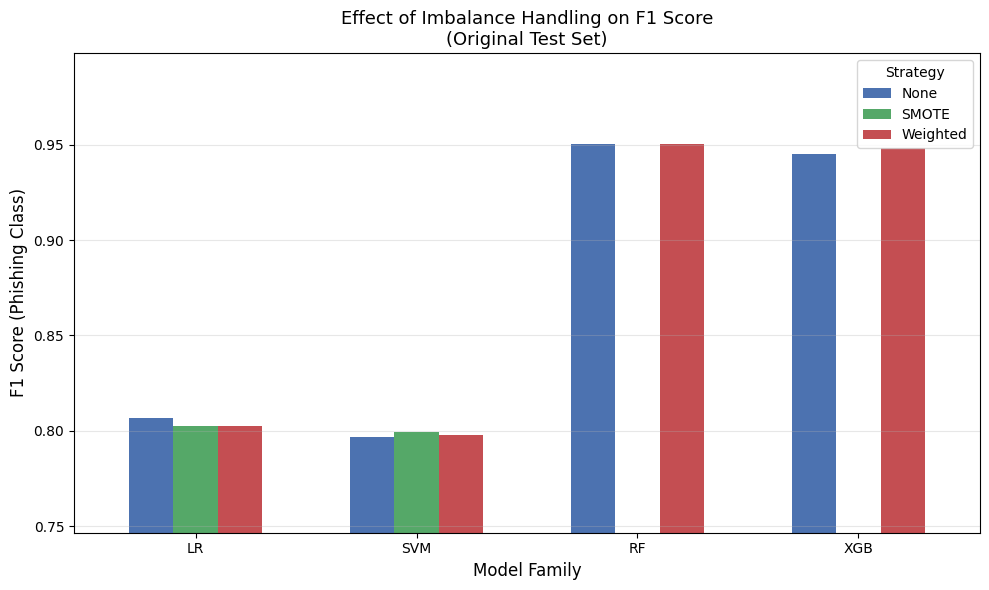

In [24]:
# Plot 1: Imbalance strategies only
# Exclude Stacking because it is an ensemble, not imbalance handling
plot_data = pivot[["None", "SMOTE", "Weighted"]].copy()

# Remove rows where all strategies are missing
plot_data = plot_data.dropna(how="all")

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.6,
    color=["#4c72b0", "#55a868", "#c44e52"]
)

ax.set_xlabel("Model Family", fontsize=12)
ax.set_ylabel("F1 Score (Phishing Class)", fontsize=12)
ax.set_title(
    "Effect of Imbalance Handling on F1 Score\n(Original Test Set)",
    fontsize=13
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Strategy")
ax.set_ylim(bottom=max(0, pivot.min().min() - 0.05))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    figure_dir / "imbalance_strategy_f1_comparison_clean.png",
    dpi=300
)
plt.show()

**Best F1 per model family (including Stacking Ensemble)**

The plot below shows the single best F1-score achieved by each model family, across all
imbalance strategies. The Stacking Ensemble is included here for a complete comparison.

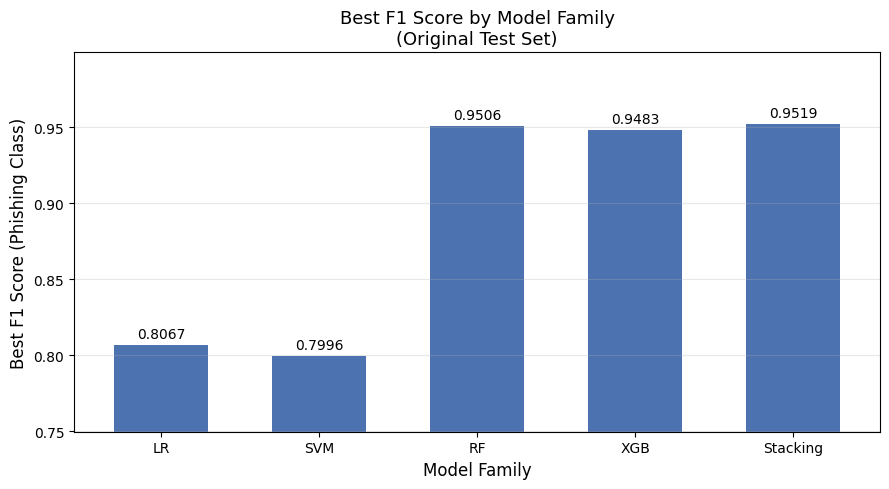


Best model per family:
                      model  strategy      f1
family                                       
LR         LR (no handling)      None  0.8067
SVM             SVM (SMOTE)     SMOTE  0.7996
RF         RF (no handling)      None  0.9506
XGB          XGB (weighted)  Weighted  0.9483
Stacking  Stacking Ensemble  Ensemble  0.9519


In [25]:
best_per_family = (
    orig.sort_values("f1", ascending=False)
    .groupby("family", as_index=False)
    .first()
)

best_per_family = best_per_family.set_index("family").reindex(family_order)
best_per_family = best_per_family.dropna(subset=["f1"])

ax = best_per_family["f1"].plot(
    kind="bar", figsize=(9, 5), width=0.6, color="#4c72b0"
)
ax.set_xlabel("Model Family", fontsize=12)
ax.set_ylabel("Best F1 Score (Phishing Class)", fontsize=12)
ax.set_title("Best F1 Score by Model Family\n(Original Test Set)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(bottom=max(0, best_per_family["f1"].min() - 0.05))
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.savefig(figure_dir / "best_f1_by_model_family_original_test.png", dpi=300)
plt.show()

print("\nBest model per family:")
print(best_per_family[["model", "strategy", "f1"]].to_string())

### Imbalance Strategy Interpretation

The results show that tree-based models substantially outperform linear models.

Key observations:
- Random Forest achieved the best individual baseline F1-score.
- XGBoost improved slightly when class weighting was applied.
- SMOTE did not significantly improve LR or SVM performance.
- The stacking ensemble achieved the highest overall F1-score, but the improvement over Random Forest was small.

This suggests that the engineered URL features are especially effective with tree-based models.

## 15. Best Model Performance Across Test Distributions

This section compares the best baseline model across multiple test-set distributions:

- Original distribution (~57/43)
- Balanced distribution (50/50)
- Imbalanced distribution (80/20)

The comparison includes:
- Accuracy,
- Precision,
- Recall,
- F1-score,
- and ROC-AUC.

Accuracy changed slightly on the balanced test set because class prevalence differs from the original distribution, making precision and recall trade-offs more visible.

This analysis evaluates how stable the model remains under different phishing prevalence conditions.

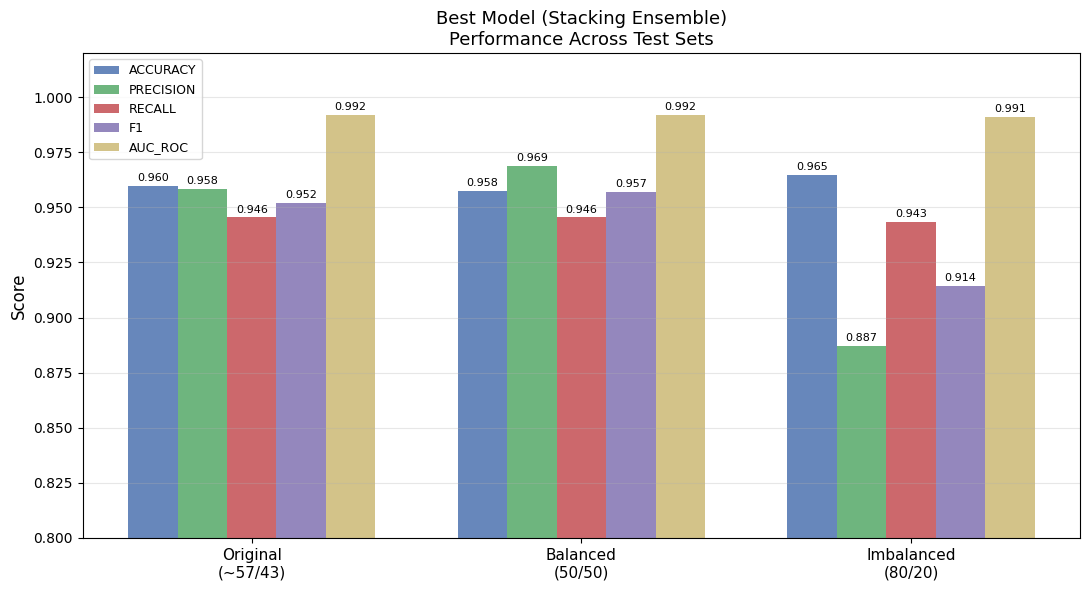

In [26]:
# Define the evaluation-set order used in the comparison plot
sets_order = ["test_original", "test_balanced_50_50", "test_imbalanced_80_20"]
set_labels = ["Original\n(~57/43)", "Balanced\n(50/50)", "Imbalanced\n(80/20)"]
metrics    = ["accuracy", "precision", "recall", "f1", "auc_roc"]
bar_colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]
# Select only the rows corresponding to the best baseline model
best_rows = (
    results_df[
        (results_df["model"] == best_name) &
        (results_df["dataset"].isin(sets_order))
    ]
    .set_index("dataset")
    .loc[sets_order]
)

x     = np.arange(len(set_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    ax.bar(x + i * width, best_rows[metric].values, width,
           label=metric.upper(), color=color, alpha=0.85)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(set_labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Best Model ({best_name})\nPerformance Across Test Sets", fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(0.80, 1.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(figure_dir / "best_model_across_test_sets.png", dpi=300)
plt.show()


### Performance Stability Analysis

The stacking ensemble maintained strong performance across all test distributions.

Key observations:
- ROC-AUC remained consistently above 0.99 across all datasets.
- F1-score decreased noticeably on the highly imbalanced 80/20 test set.
- Precision decreased on the imbalanced test set partly because phishing URLs became less prevalent, making false positives proportionally more influential.
- Recall remained relatively stable, indicating that the model continued detecting most phishing URLs even under imbalance.

These results suggest that the ensemble generalizes well across different phishing prevalence scenarios.

## 15.1 Threshold Sensitivity Analysis

The default classification threshold is 0.5: a URL is predicted as phishing if its probability score
is ≥ 0.5. This threshold can be adjusted to trade off between precision and recall.

In security applications, a **lower threshold** is often preferred because:
- It increases **recall** — more phishing URLs are caught.
- It increases **FNR cost** — missing a phishing URL is more dangerous than a false alarm.

This analysis evaluates the best baseline model (selected in Section 10) across thresholds
from 0.1 to 0.9 and tracks how Precision, Recall, F1-score, and False Negative Rate (FNR) change.

The analysis helps identify operating points suitable for different deployment contexts:
- **Browser plugin** (low latency, some false alarms acceptable): moderate threshold.
- **Corporate firewall** (zero tolerance for missed phishing): lower threshold.

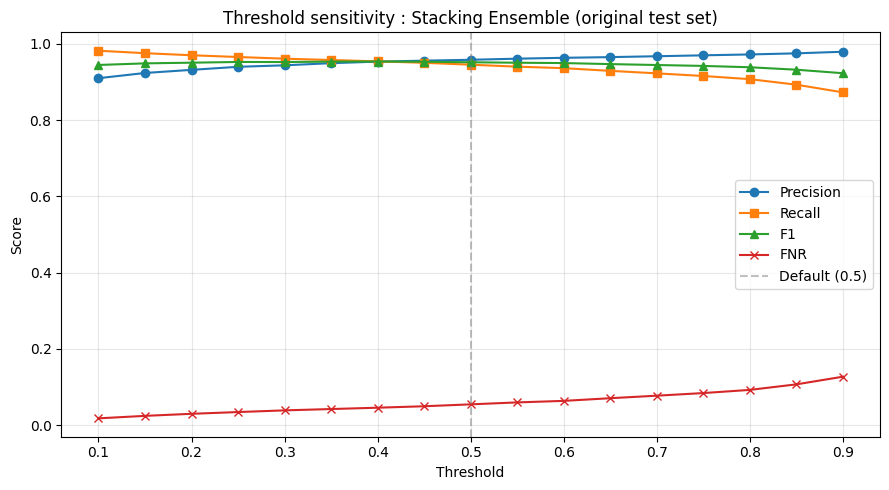

    threshold  precision  recall      f1     fnr
0        0.10     0.9101  0.9822  0.9448  0.0178
1        0.15     0.9238  0.9757  0.9490  0.0243
2        0.20     0.9320  0.9703  0.9508  0.0297
3        0.25     0.9400  0.9657  0.9527  0.0343
4        0.30     0.9439  0.9613  0.9525  0.0387
5        0.35     0.9495  0.9578  0.9536  0.0422
6        0.40     0.9536  0.9543  0.9539  0.0457
7        0.45     0.9561  0.9505  0.9533  0.0495
8        0.50     0.9584  0.9455  0.9519  0.0545
9        0.55     0.9613  0.9404  0.9507  0.0596
10       0.60     0.9636  0.9364  0.9498  0.0636
11       0.65     0.9654  0.9294  0.9471  0.0706
12       0.70     0.9677  0.9228  0.9447  0.0772
13       0.75     0.9701  0.9159  0.9423  0.0841
14       0.80     0.9724  0.9076  0.9388  0.0924
15       0.85     0.9753  0.8931  0.9324  0.1069
16       0.90     0.9795  0.8730  0.9232  0.1270


In [27]:
y_prob_best = get_probabilities(best_model, X_te_u)
rows = []
for t in np.arange(0.1, 0.95, 0.05):
    yp = (y_prob_best >= t).astype(int)
    tp = int(((yp==1)&(y_te==1)).sum())
    fp = int(((yp==1)&(y_te==0)).sum())
    fn = int(((yp==0)&(y_te==1)).sum())
    tn = int(((yp==0)&(y_te==0)).sum())
    rows.append({
        'threshold': round(t, 2),
        'precision': round(tp/(tp+fp+1e-9), 4),
        'recall':    round(tp/(tp+fn+1e-9), 4),
        'f1':        round(2*tp/(2*tp+fp+fn+1e-9), 4),
        'fnr':       round(fn/(fn+tp+1e-9), 4),
    })

thresh_df = pd.DataFrame(rows)
thresh_df.to_csv(report_table_dir / 'threshold_sensitivity.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
labels = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1', 'fnr': 'FNR'}
for col, marker in [('precision','o'),('recall','s'),('f1','^'),('fnr','x')]:
    ax.plot(thresh_df['threshold'], thresh_df[col],
            label=labels[col], marker=marker)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold sensitivity : {best_name} (original test set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figure_dir / 'threshold_sensitivity.png', dpi=300)
plt.show()
print(thresh_df)

### Threshold Sensitivity Interpretation

The plot shows the trade-off between precision and recall as the classification threshold changes.

Key observations:
- At the default threshold (0.5), the model achieves balanced Precision and Recall.
- Lowering the threshold below 0.5 increases Recall (fewer missed phishing URLs) but decreases
  Precision (more legitimate URLs are flagged as phishing).
- Raising the threshold above 0.5 increases Precision but allows more phishing URLs to pass through.
- For security-critical deployment, a threshold between 0.3 and 0.4 may be preferable because
  it reduces FNR while keeping FPR within an acceptable range.

The threshold sensitivity table is saved to `reports/tables/threshold_sensitivity.csv`
and the plot is saved to `reports/figures/threshold_sensitivity.png`.

## 16. Error Analysis — False Positives and False Negatives

This section analyzes the mistakes made by the best baseline model on the original test set.

Two error types are examined:

| Error Type | Meaning |
|---|---|
| False Positive (FP) | Legitimate URL predicted as phishing |
| False Negative (FN) | Phishing URL predicted as legitimate |

The analysis includes:
- error counts,
- FPR/FNR computation,
- URL length distributions,
- and example misclassified URLs.

Error analysis helps identify the limitations of the phishing detector and provides insight into difficult URL patterns.

False Positives (legitimate → predicted phishing): 337
False Negatives (phishing → predicted legitimate): 448
FPR = 0.0300
FNR = 0.0545


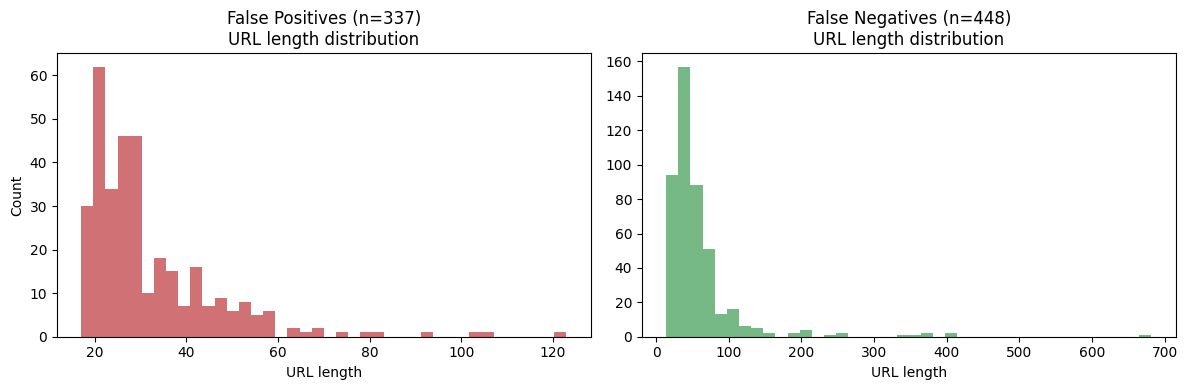


Sample False Positives (legitimate URLs flagged as phishing):
47                           https://giphy.com/A1eSports
67                                  https://goo.gl/3rng4
80                                 http://duckduckgo.com
130      http://googleusercontent.com/youtube_content/10
134                          http://bizschool.naver.com/
160    https://research.easebar.com/htmls/f0pci3/pape...
185               https://php.net/badmethodcallexception
325             https://giphy.com/anchorbayentertainment

Sample False Negatives (phishing URLs missed by model):
82                    https://fss3v.app.link/eBs6XEP39Hb
98                               https://ozboya.com/ups/
99     https://kundeservice-portal-kundestotte-moujta...
123    https://fc9242df64.nxcli.io/wp-includes/swissc...
149    https://truegrip.com/validez-votre-paiement-le...
157                 https://www.flowcode.com/page/lattee
167    https://www.tray.com.br/shopee/?utm_campaign=n...
203    https://lp.constan

In [28]:
# Load the original raw test URLs for interpretability and error inspection
test_raw = pd.read_csv(feature_dir / "test.csv")

# Generate predictions using the selected best baseline model
X_eval = X_te_u if use_unscaled else X_te_s
y_pred_best = best_model.predict(X_eval)

error_df          = test_raw.copy()
error_df["y_true"] = y_te
error_df["y_pred"] = y_pred_best

# False positives:
# legitimate URLs incorrectly classified as phishing

# False negatives:
# phishing URLs incorrectly classified as legitimate
false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]
false_negatives = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

print(f"False Positives (legitimate → predicted phishing): {len(false_positives):,}")
print(f"False Negatives (phishing → predicted legitimate): {len(false_negatives):,}")
print(f"FPR = {len(false_positives) / (y_te == 0).sum():.4f}")
print(f"FNR = {len(false_negatives) / (y_te == 1).sum():.4f}")

false_positives.to_csv(report_table_dir / "false_positives_best_model.csv",  index=False)
false_negatives.to_csv(report_table_dir / "false_negatives_best_model.csv",  index=False)

# ── URL length distribution of errors ────────────────────────────────────────
fp_len = false_positives["URL"].str.len()
fn_len = false_negatives["URL"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fp_len, bins=40, color="#c44e52", alpha=0.8)
axes[0].set_title(f"False Positives (n={len(fp_len):,})\nURL length distribution")
axes[0].set_xlabel("URL length")
axes[0].set_ylabel("Count")

axes[1].hist(fn_len, bins=40, color="#55a868", alpha=0.8)
axes[1].set_title(f"False Negatives (n={len(fn_len):,})\nURL length distribution")
axes[1].set_xlabel("URL length")

plt.tight_layout()
plt.savefig(figure_dir / "error_url_length_distribution.png", dpi=300)
plt.show()

print("\nSample False Positives (legitimate URLs flagged as phishing):")
print(false_positives["URL"].head(8).to_string())

print("\nSample False Negatives (phishing URLs missed by model):")
print(false_negatives["URL"].head(8).to_string())


### Error Analysis Interpretation

The best baseline model produced:
- 337 false positives,
- and 448 false negatives
on the original test set.

Key observations:
- False negatives are more dangerous because phishing URLs bypass detection.
- Many false-negative URLs contain shortened links, redirect-style structures, or realistic-looking domains.
- Some legitimate URLs were falsely flagged because they contain long paths, special characters, or patterns commonly associated with phishing URLs.
- False-negative URLs generally show greater variability in URL length and structure.

This analysis suggests that certain phishing URLs successfully mimic legitimate URL patterns, making detection more difficult.

## 17. Final Summary Table for Report

This section creates the final summary table used in the project report.

The table compares all baseline models across:
- original test distribution,
- balanced test distribution,
- and imbalanced test distribution.

The reported metrics include:
- Accuracy,
- Precision,
- Recall,
- F1-score,
- ROC-AUC,
- and False Positive Rate (FPR).

The results are sorted by F1-score within each dataset distribution to highlight the strongest-performing models.

In [29]:
summary = (
    results_df[
        results_df["dataset"].isin(
            ["test_original", "test_balanced_50_50", "test_imbalanced_80_20"]
        )
    ]
    .sort_values(["dataset", "f1"], ascending=[True, False])
    [["model", "dataset", "accuracy", "precision", "recall", "f1", "auc_roc", "fpr","fnr"]]
)

summary.to_csv(report_table_dir / "baseline_summary_for_report.csv", index=False)
print("Saved at reports/tables/baseline_summary_for_report.csv\n")

for ds in ["test_original", "test_balanced_50_50", "test_imbalanced_80_20"]:
    print(f"\n {ds} ")
    print(summary[summary["dataset"] == ds].drop(columns="dataset").to_string(index=False))


Saved at reports/tables/baseline_summary_for_report.csv


 test_original 
            model  accuracy  precision  recall     f1  auc_roc    fpr    fnr
Stacking Ensemble    0.9597     0.9584  0.9455 0.9519   0.9918 0.0300 0.0545
 RF (no handling)    0.9588     0.9607  0.9408 0.9506   0.9919 0.0281 0.0592
    RF (weighted)    0.9584     0.9562  0.9448 0.9504   0.9918 0.0317 0.0552
   XGB (weighted)    0.9563     0.9478  0.9488 0.9483   0.9905 0.0382 0.0512
XGB (no handling)    0.9543     0.9550  0.9360 0.9454   0.9903 0.0323 0.0640
 LR (no handling)    0.8411     0.8295  0.7852 0.8067   0.9115 0.1180 0.2148
       LR (SMOTE)    0.8284     0.7801  0.8267 0.8027   0.9114 0.1704 0.1733
    LR (weighted)    0.8284     0.7805  0.8261 0.8026   0.9114 0.1698 0.1739
      SVM (SMOTE)    0.8261     0.7789  0.8214 0.7996   0.9080 0.1705 0.1786
   SVM (weighted)    0.8350     0.8273  0.7701 0.7977   0.9077 0.1176 0.2299
SVM (no handling)    0.8344     0.8280  0.7673 0.7965   0.9075 0.1165 0.2327

 

### Final Baseline Summary

The final results show a clear performance gap between linear models and tree-based models.

Key findings:
- The Stacking Ensemble achieved best on original and balanced test sets.
- Random Forest consistently achieved the strongest individual baseline performance.
- XGBoost also performed strongly, especially with class weighting.
- Logistic Regression and SVM showed substantially lower F1-score and ROC-AUC values.
- Tree-based models maintained strong robustness under both balanced and imbalanced test conditions.

Overall, the experiments suggest that engineered lexical URL features are highly effective when combined with nonlinear ensemble models.

## 17.1 CPU Inference Time Benchmark

Training time was recorded in Section 6. This section measures **inference time** —
how fast each model classifies a new URL at prediction time.

Inference speed is important for real-world deployment scenarios such as:
- Browser plugins that must classify URLs in real time.
- Network firewalls processing thousands of requests per second.

Four representative models are benchmarked on 1,000 test URLs (CPU only):

| Model | Type |
|---|---|
| LR (no handling) | Linear baseline — fastest expected |
| RF (no handling) | Tree ensemble — moderate speed |
| XGB (weighted)   | Gradient boosting — fastest tree model |
| Stacking Ensemble | Combined model — slowest expected |

Inference time is reported in milliseconds per URL (ms/URL).
Lower is better for deployment-sensitive applications.

In [30]:
inference_rows = []
for name, model, X_s in [
    ('LR (no handling)',   lr_none,      X_te_s[:1000]),
    ('RF (no handling)',   rf_none,      X_te_u[:1000]),
    ('XGB (weighted)',     xgb_weighted, X_te_u[:1000]),
    ('Stacking Ensemble',  best_model,   X_te_u[:1000]),
]:
    t0 = time.time()
    _ = model.predict(X_s)
    elapsed_sec = time.time() - t0
    ms_per_url = (elapsed_sec * 1000) / 1000   # convert to ms, divide by 1000 samples
    inference_rows.append({'model': name, 'ms_per_url': round(ms_per_url, 4)})
    print(f"{name}: {ms_per_url:.4f} ms/URL")

pd.DataFrame(inference_rows).to_csv(
    report_table_dir / 'classical_inference_time.csv', index=False)

LR (no handling): 0.0006 ms/URL
RF (no handling): 0.1202 ms/URL
XGB (weighted): 0.0077 ms/URL
Stacking Ensemble: 0.1388 ms/URL


### Inference Time Interpretation

Key observations:
- Logistic Regression is the fastest model due to its simple linear computation.
- XGBoost is substantially faster than Random Forest at inference time because gradient-boosted
  trees use shallower trees, while Random Forest uses many deep trees that must all be traversed.
- The Stacking Ensemble is the slowest because it runs all three base models before the meta-learner.
- All classical models produce inference times well under 1 ms/URL on CPU, confirming they are
  deployable in real-time browser plugin environments.

The inference time table is saved to `reports/tables/classical_inference_time.csv`.

## 18. Final Comparison Table: Classical + Deep Learning Models

In [31]:
# Backfills CM values into results_df, builds the joint table, patches the
# final CSV, and prints per-distribution summaries_all in one place.

# Constants
CM_COLS         = ["tp", "fp", "fn", "tn"]
CLASSICAL_MODELS = ["Stacking Ensemble", "RF (no handling)", "XGB (weighted)"]
DISTRIBUTIONS   = ["test_original", "test_balanced_50_50", "test_imbalanced_80_20"]

FINAL_COLS = [
    "Type", "Model",
    "Params (M)", "Trained Params (M)",
    "Test Distribution",
    "Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score",
    "FPR", "FNR", "TN", "FP", "FN", "TP",
    "ms per URL",
    "Efficiency (f1-score/M parameter)",
]
DISPLAY_COLS = [
      "Type", "Model", "F1 Score", "Roc Auc Score",
      "Precision", "Recall", "FPR", "FNR",
      "ms per URL", "Params (M)", "Efficiency (f1-score/M parameter)",
]
NUMERIC_COLS = ["Accuracy", "Precision", "Recall", "F1 Score",
                "Roc Auc Score", "FPR", "FNR"]

In [32]:
# Step 1: Backfill TN/FP/FN/TP into results_df from all_results
cm_lookup = {
    (r["model"], r["dataset"]): {k: r[k] for k in CM_COLS}
    for r in all_results
    if all(k in r for k in CM_COLS)
}

for col in CM_COLS:
    if col not in results_df.columns:
        results_df[col] = None

for idx, row in results_df.iterrows():
    key = (row["model"], row["dataset"])
    if key in cm_lookup:
        for col in CM_COLS:
            results_df.at[idx, col] = cm_lookup[key][col]

results_df.to_csv(report_table_dir / "baseline_all_results.csv", index=False)
print("Updated baseline_all_results.csv with TN/FP/FN/TP values")

Updated baseline_all_results.csv with TN/FP/FN/TP values


In [34]:
# Step 2: Build classical rows
infer_df = pd.read_csv(report_table_dir / 'classical_inference_time.csv')
infer_map = dict(zip(infer_df["model"], infer_df["ms_per_url"]))

classical_rows = []
for dist in DISTRIBUTIONS:
    subset = results_df[
        (results_df["dataset"] == dist) &
        (results_df["model"].isin(CLASSICAL_MODELS))
    ][["model", "accuracy", "precision", "recall", "f1", "auc_roc",
       "fpr", "fnr", "tp", "fp", "fn", "tn"]].copy()

    subset.rename(columns={
        "model": "Model", "accuracy": "Accuracy", "precision": "Precision",
        "recall": "Recall", "f1": "F1 Score", "auc_roc": "Roc Auc Score",
        "fpr": "FPR", "fnr": "FNR",
        "tp": "TP", "fp": "FP", "fn": "FN", "tn": "TN",
    }, inplace=True)

    subset["Type"]               = "Classical"
    subset["Params (M)"]         = "N/A"
    subset["Trained Params (M)"] = "N/A"
    subset["Efficiency (f1-score/M parameter)"] = "N/A"
    subset["ms per URL"]         = subset["Model"].map(infer_map)
    subset["Test Distribution"]  = dist
    classical_rows.append(subset)

classical_df = pd.concat(classical_rows, ignore_index=True)

In [35]:
# Step 3: Build deep learning rows
deep_files = [
    (deep_csv / "results_original_test_distribution.csv",   "test_original"),
    (deep_csv / "results_balanced_test_distribution.csv",   "test_balanced_50_50"),
    (deep_csv / "results_imbalanced_test_distribution.csv", "test_imbalanced_80_20"),
]

deep_parts = []
for path, label in deep_files:
    df = pd.read_csv(path)
    df["Test Distribution"] = label
    df["Type"] = "Deep"
    deep_parts.append(df)

deep_df = pd.concat(deep_parts, ignore_index=True)
deep_df["FPR"] = (deep_df["FP"] / (deep_df["FP"] + deep_df["TN"])).round(4)
deep_df["FNR"] = (deep_df["FN"] / (deep_df["FN"] + deep_df["TP"])).round(4)

In [36]:
# Step 4: Merge, align, sort, and save
for col in FINAL_COLS:
    if col not in classical_df.columns: classical_df[col] = "N/A"
    if col not in deep_df.columns:      deep_df[col]      = "N/A"

joint = pd.concat(
    [classical_df[FINAL_COLS], deep_df[FINAL_COLS]],
    ignore_index=True,
)
joint[NUMERIC_COLS] = joint[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").round(4)
joint.sort_values(["Test Distribution", "F1 Score"], ascending=[True, False], inplace=True)
joint.reset_index(drop=True, inplace=True)

final_csv_path = report_table_dir / "final_all_models_comparison.csv"
joint.to_csv(final_csv_path, index=False)
print(f"Saved final_all_models_comparison.csv  ({len(joint)} rows: {len(classical_df)} classical + {len(deep_df)} deep)")

Saved final_all_models_comparison.csv  (27 rows: 9 classical + 18 deep)


In [37]:
# Step 5: Patch classical CM values into saved CSV & verify
final_df = pd.read_csv(final_csv_path)

cm_patch = (
    results_df[["model", "dataset", "tp", "fp", "fn", "tn"]]
    .rename(columns={"model": "Model", "dataset": "Test Distribution"})
    .set_index(["Model", "Test Distribution"])
    .to_dict("index")
)

for idx, row in final_df.iterrows():
    key = (row["Model"], row["Test Distribution"])
    if key in cm_patch:
        for col in ["TP", "FP", "FN", "TN"]:
            final_df.at[idx, col] = cm_patch[key][col.lower()]

final_df.to_csv(final_csv_path, index=False)
print("Patched classical TN/FP/FN/TP into final_all_models_comparison.csv")
print(
    final_df[final_df["Type"] == "Classical"]
    [["Model", "Test Distribution", "TN", "FP", "FN", "TP"]]
    .to_string(index=False)
)

Patched classical TN/FP/FN/TP into final_all_models_comparison.csv
            Model     Test Distribution    TN  FP  FN   TP
Stacking Ensemble   test_balanced_50_50  7972 249 448 7773
 RF (no handling)   test_balanced_50_50  7990 231 487 7734
   XGB (weighted)   test_balanced_50_50  7902 319 421 7800
 RF (no handling) test_imbalanced_80_20 10930 316 173 2638
Stacking Ensemble test_imbalanced_80_20 10909 337 159 2652
   XGB (weighted) test_imbalanced_80_20 10816 430 154 2657
Stacking Ensemble         test_original 10909 337 448 7773
 RF (no handling)         test_original 10930 316 487 7734
   XGB (weighted)         test_original 10816 430 421 7800


In [38]:
# Step 6: Print per-distribution summary tables
for dist in DISTRIBUTIONS:
    print(f"\n{'='*80}\n  Distribution: {dist}\n{'='*80}")
    print(final_df[final_df["Test Distribution"] == dist][DISPLAY_COLS].to_string(index=False))


  Distribution: test_original
     Type                Model  F1 Score  Roc Auc Score  Precision  Recall    FPR    FNR  ms per URL  Params (M)  Efficiency (f1-score/M parameter)
     Deep         CNN-Fasttext    0.9938         0.9951     0.9905  0.9972 0.0070 0.0028      0.7775    5.339861                           1.586146
     Deep             Char-CNN    0.9926         0.9933     0.9950  0.9901 0.0036 0.0099      2.0375    0.179329                           5.722764
     Deep   Hybrid Fusion-Full    0.9926         0.9931     0.9964  0.9888 0.0026 0.0112      1.9102    0.193153                           5.300577
     Deep Hybrid Fusion Top 50    0.9926         0.9934     0.9943  0.9910 0.0042 0.0090      1.9991    0.192257                           5.326147
     Deep Hybrid Fusion Top 25    0.9925         0.9933     0.9943  0.9908 0.0042 0.0092      1.9038    0.192001                           5.332814
     Deep           CNN-BiLSTM    0.9920         0.9934     0.9901  0.9940 0.0073

## 19. Final Deliverables Checklist

In [41]:
deliverables = [
    (report_table_dir, "baseline_all_results.csv"),
    (report_table_dir, "baseline_test_orig_comparison.csv"),
    (report_table_dir, "imbalance_strategy_f1_comparison.csv"),
    (report_table_dir, "baseline_summary_for_report.csv"),
    (report_table_dir, "feature_importance_rf.csv"),
    (report_table_dir, "false_positives_best_model.csv"),
    (report_table_dir, "false_negatives_best_model.csv"),
    (figure_dir,       "feature_importance_rf.png"),
    (figure_dir,       "roc_curves_all_models.png"),
    (figure_dir,       "confusion_matrices_best_model.png"),
    (figure_dir, "imbalance_strategy_f1_comparison_clean.png"),
    (figure_dir, "best_f1_by_model_family_original_test.png"),
    (figure_dir,       "best_model_across_test_sets.png"),
    (figure_dir,       "error_url_length_distribution.png"),
    (models_dir,       "best_baseline_model.joblib"),
    (report_table_dir, "feature_ablation_results.csv"),
    (report_table_dir, "threshold_sensitivity.csv"),
    (figure_dir,       "threshold_sensitivity.png"),
    (report_table_dir, "classical_inference_time.csv"),
]

all_ok = True
for folder, fname in deliverables:
    path   = folder / fname
    status = "Exist" if path.exists() else "MISSING"
    if not path.exists():
        all_ok = False
    print(f"  {status}  {path.relative_to(BASE)}")

print()
print("All files Done!" if all_ok else "Some files are missing_re-run the relevant cells.")


  Exist  reports/tables/baseline_all_results.csv
  Exist  reports/tables/baseline_test_orig_comparison.csv
  Exist  reports/tables/imbalance_strategy_f1_comparison.csv
  Exist  reports/tables/baseline_summary_for_report.csv
  Exist  reports/tables/feature_importance_rf.csv
  Exist  reports/tables/false_positives_best_model.csv
  Exist  reports/tables/false_negatives_best_model.csv
  Exist  reports/figures/feature_importance_rf.png
  Exist  reports/figures/roc_curves_all_models.png
  Exist  reports/figures/confusion_matrices_best_model.png
  Exist  reports/figures/imbalance_strategy_f1_comparison_clean.png
  Exist  reports/figures/best_f1_by_model_family_original_test.png
  Exist  reports/figures/best_model_across_test_sets.png
  Exist  reports/figures/error_url_length_distribution.png
  Exist  models/best_baseline_model.joblib
  Exist  reports/tables/feature_ablation_results.csv
  Exist  reports/tables/threshold_sensitivity.csv
  Exist  reports/figures/threshold_sensitivity.png
  Exist

## Referance

| Related Paper | Title | DOI |
|---|-------|-----|
| 1 | Real-Time Phishing Detection Using Machine Learning on URL Features | [10.1109/ICONAT66879.2025.11362893](https://doi.org/10.1109/ICONAT66879.2025.11362893) |
| 2 | Phishing Detection Using Machine Learning with Advanced URL Feature Engineering and Stacking Ensemble Approach | [10.1109/ICIPTM69057.2026.11466278](https://doi.org/10.1109/ICIPTM69057.2026.11466278) |
| 3 | Phishing URL Detection Using Machine Learning Methods | [10.1016/j.advengsoft.2022.103288](https://doi.org/10.1016/j.advengsoft.2022.103288) |
| 4 | XGBoost: A Scalable Tree Boosting System | [10.48550/arXiv.1603.02754](https://doi.org/10.48550/arXiv.1603.02754) |
| 5 | SMOTE: Synthetic Minority Over-sampling Technique | [10.1613/jair.953](https://doi.org/10.1613/jair.953) |